# Exercício

Problema: prever se um passageiro sobreviveu ao naufrágio do Titanic.

Features: `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`

Target: `survived` (0 = não, 1 = sim)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

## 1. Carregando e explorando o dataset

In [2]:
titanic = sns.load_dataset('titanic')
colunas_usar = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df = titanic[colunas_usar].copy()
print(f'Dimensoes: {df.shape}')
print(f'Valores nulos:')
print(df.isnull().sum())
df.head(10)

Dimensoes: (891, 8)
Valores nulos:
survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
5,0,3,male,NaN,0,0,8.4583,Q
6,0,1,male,54.0,0,0,51.8625,S
7,0,3,male,2.0,3,1,21.0750,S
8,1,3,female,27.0,0,2,11.1333,S
9,1,2,female,14.0,1,0,30.0708,C


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


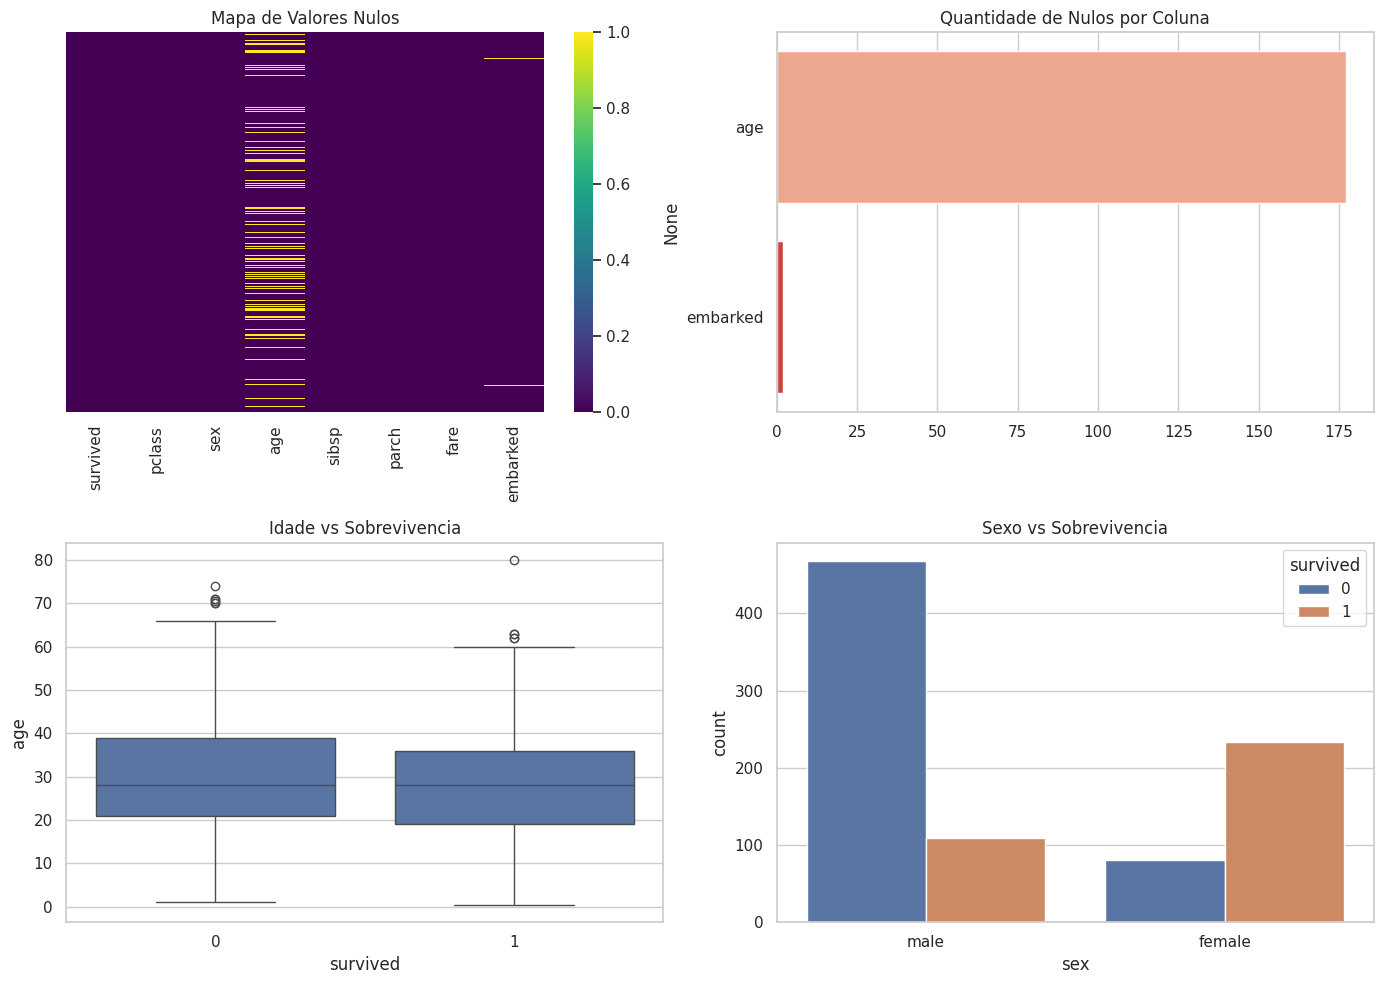

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Mapa de Valores Nulos')
nulos = df.isnull().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
sns.barplot(x=nulos.values, y=nulos.index, palette='Reds', ax=axes[0, 1])
axes[0, 1].set_title('Quantidade de Nulos por Coluna')
sns.boxplot(data=df, x='survived', y='age', ax=axes[1, 0])
axes[1, 0].set_title('Idade vs Sobrevivencia')
sns.countplot(data=df, x='sex', hue='survived', ax=axes[1, 1])
axes[1, 1].set_title('Sexo vs Sobrevivencia')
plt.tight_layout()
plt.show()

---
## 2. Separando treino/teste

In [5]:
X = df.drop(columns=['survived'])
y = df['survived']
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
colunas_numericas = ['age', 'sibsp', 'parch', 'fare']
colunas_categoricas = ['sex', 'embarked']
colunas_ordinais = ['pclass']
print(f'Treino: {X_treino.shape[0]}  |  Teste: {X_teste.shape[0]}')

Treino: 712  |  Teste: 179


---
## 3. Pipeline completo (baseline)

Etapas: imputacao (mediana/moda) -> escalonamento (StandardScaler) -> encoding (OneHotEncoder) -> LogisticRegression

In [6]:
pipeline_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
pipeline_categorico = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first'))
])
preprocessador = ColumnTransformer([
    ('numericas', pipeline_numerico, colunas_numericas),
    ('categoricas', pipeline_categorico, colunas_categoricas),
    ('ordinais', 'passthrough', colunas_ordinais)
])
pipeline_completo = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])
pipeline_completo.fit(X_treino, y_treino)
y_pred = pipeline_completo.predict(X_teste)
acc_base = accuracy_score(y_teste, y_pred)
print(f'Acurácia (Pipeline completo): {acc_base:.4f}  ({acc_base*100:.1f}%)')
print()
print(classification_report(y_teste, y_pred, target_names=['Nao Sobreviveu', 'Sobreviveu']))

Acurácia (Pipeline completo): 0.8045  (80.4%)

                precision    recall  f1-score   support

Nao Sobreviveu       0.81      0.89      0.85       110
    Sobreviveu       0.79      0.67      0.72        69

      accuracy                           0.80       179
     macro avg       0.80      0.78      0.79       179
  weighted avg       0.80      0.80      0.80       179



---
## 4. Experimento 1: Estrategias de imputacao (median vs mean vs constant)

In [7]:
resultados = []
for estrat in ['median', 'mean']:
    pn = Pipeline([('imputer', SimpleImputer(strategy=estrat)), ('scaler', StandardScaler())])
    prep = ColumnTransformer([('num', pn, colunas_numericas), ('cat', pipeline_categorico, colunas_categoricas), ('ord', 'passthrough', colunas_ordinais)])
    pipe = Pipeline([('prep', prep), ('modelo', LogisticRegression(max_iter=1000, random_state=42))])
    pipe.fit(X_treino, y_treino)
    resultados.append({'Estrategia': estrat, 'Acuracia': accuracy_score(y_teste, pipe.predict(X_teste))})
pd.DataFrame(resultados).set_index('Estrategia')

,Acuracia
Estrategia,
median,0.804469
mean,0.798883


---
## 5. Experimento 2: StandardScaler vs MinMaxScaler

In [8]:
resultados_s = []
for nome, scaler in [('StandardScaler', StandardScaler()), ('MinMaxScaler', MinMaxScaler())]:
    pn = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', scaler)])
    prep = ColumnTransformer([('num', pn, colunas_numericas), ('cat', pipeline_categorico, colunas_categoricas), ('ord', 'passthrough', colunas_ordinais)])
    pipe = Pipeline([('prep', prep), ('modelo', LogisticRegression(max_iter=1000, random_state=42))])
    pipe.fit(X_treino, y_treino)
    resultados_s.append({'Scaler': nome, 'Acuracia': accuracy_score(y_teste, pipe.predict(X_teste))})
pd.DataFrame(resultados_s).set_index('Scaler')

,Acuracia
Scaler,
StandardScaler,0.804469
MinMaxScaler,0.798883


---
## 6. Experimento 3: Modelos diferentes dentro do pipeline

In [9]:
resultados_m = []
modelos = [
    ('Regressao Logistica', LogisticRegression(max_iter=1000, random_state=42)),
    ('Arvore de Decisao (depth=4)', DecisionTreeClassifier(max_depth=4, random_state=42)),
    ('Arvore de Decisao (depth=8)', DecisionTreeClassifier(max_depth=8, random_state=42)),
]
for nome, modelo in modelos:
    pipe = Pipeline([('prep', preprocessador), ('modelo', modelo)])
    pipe.fit(X_treino, y_treino)
    acc_test = accuracy_score(y_teste, pipe.predict(X_teste))
    cv = cross_val_score(pipe, X, y, cv=5).mean()
    resultados_m.append({'Modelo': nome, 'Acuracia Teste': acc_test, 'Acuracia CV5': cv})
pd.DataFrame(resultados_m).set_index('Modelo').style.format('{:.4f}')

,Acuracia Teste,Acuracia CV5
Modelo,,
Regressao Logistica,0.8045,0.7901
Arvore de Decisao (depth=4),0.7821,0.8059
Arvore de Decisao (depth=8),0.7989,0.8149


---
## 7. Experimento 4: O que acontece sem pre-processamento?

In [10]:
print(f'{"Configuracao":<45} {"Acuracia":>10}')
print('-' * 58)
print(f'{"Pipeline completo (baseline)":<45} {acc_base:>10.4f}')

def testar(nome, coltrans):
    try:
        pipe = Pipeline([('prep', coltrans), ('modelo', LogisticRegression(max_iter=1000, random_state=42))])
        pipe.fit(X_treino, y_treino)
        acc = accuracy_score(y_teste, pipe.predict(X_teste))
        print(f'{nome:<45} {acc:>10.4f}')
    except Exception as e:
        print(f'{nome:<45} {"ERRO":>10}')

prep_sem_imput = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), colunas_numericas),
    ('cat', OneHotEncoder(drop='first'), colunas_categoricas),
    ('ord', 'passthrough', colunas_ordinais)
])
testar('Sem imputacao (nulos nao tratados)', prep_sem_imput)

prep_sem_scaler = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), colunas_numericas),
    ('cat', pipeline_categorico, colunas_categoricas),
    ('ord', 'passthrough', colunas_ordinais)
])
testar('Sem escalonamento', prep_sem_scaler)

prep_sem_nada = ColumnTransformer([
    ('num', 'passthrough', colunas_numericas),
    ('cat', OneHotEncoder(drop='first'), colunas_categoricas),
    ('ord', 'passthrough', colunas_ordinais)
])
testar('Sem imputacao E sem escalonamento', prep_sem_nada)

print('-' * 58)

Configuracao                                    Acuracia
----------------------------------------------------------
Pipeline completo (baseline)                      0.8045
Sem imputacao (nulos nao tratados)                  ERRO
Sem escalonamento                                 0.8045
Sem imputacao E sem escalonamento                   ERRO
----------------------------------------------------------


---
## 8. Respondendo as perguntas do exercicio

### 1. Qual estrategia deu o melhor resultado? Por que?

A **mediana ('median')** geralmente e a melhor escolha para a idade, porque:
- A idade tem outliers (passageiros muito jovens ou muito idosos).
- A mediana e resistente a outliers, ao contrario da media.
- A media pode ser puxada por valores extremos e distorcer a imputacao.

Para o porto de embarque, a **moda ('most_frequent')** e a escolha natural por ser categorico.

### 2. O que acontece se voce NAO escalonar os dados?

O modelo pode **funcionar, mas com acuracia reduzida**, especialmente com Regressao Logistica. Sem escalonamento:
- A coluna `fare` (tarifa, valores ate 512) domina completamente colunas como `sibsp` (0-8) ou `parch` (0-6).
- O otimizador da Regressao Logistica converge mais lentamente ou fica instavel.
- Modelos baseados em distancia (como SVM ou KNN) seriam ainda mais afetados.

Nota: Arvores de Decisao **nao precisam** de escalonamento — essa e uma das vantagens delas.

### 3. O que acontece se voce nao tratar os valores nulos?

**O modelo quebra.** O scikit-learn lanca um erro quando encontra `NaN` nos dados de entrada. Nao e possivel treinar um modelo com valores nulos — o pre-processamento de nulos e obrigatorio, nao opcional.

Isso demonstra por que o pre-processamento e a etapa mais importante: sem ele, o modelo sequer consegue rodar.